In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [16]:
train = pd.read_csv('train.csv')


In [4]:
from google.colab import files

uploaded = files.upload()

Saving test.csv to test.csv


In [17]:
test = pd.read_csv('test.csv')

In [18]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [20]:

train.shape

(891, 12)

In [21]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [22]:
train = train.drop(['Cabin','Ticket','Name','PassengerId'],axis=1)


In [23]:
train.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [24]:
freq = train.Embarked.dropna().mode()
print(freq,'\n')
train['Embarked'] = train['Embarked'].fillna(freq[0]) # fill "NAN" values with the most frequent value

mean = train['Age'].dropna().mean()
train['Age'] = train['Age'].fillna(round(mean))
print(round(mean))

0    S
Name: Embarked, dtype: object 

30


In [25]:
train['Sex'].replace('female', 0,inplace=True)
train['Sex'].replace('male', 1,inplace=True)


train['Embarked'].replace('S', 0,inplace=True)
train['Embarked'].replace('C', 1,inplace=True)
train['Embarked'].replace('Q', 2,inplace=True)

/tmp/ipykernel_4675/2679372075.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Sex'].replace('female', 0,inplace=True)
/tmp/ipykernel_4675/2679372075.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

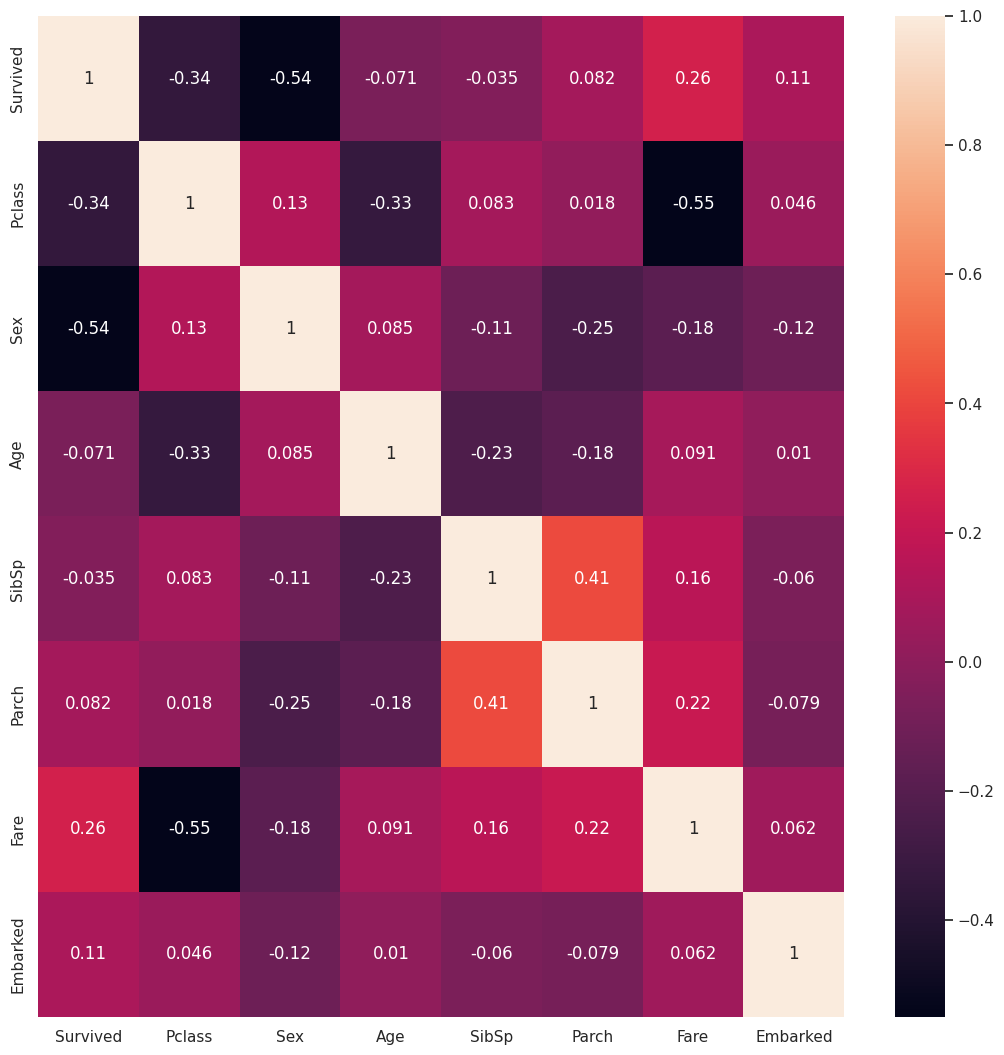

In [26]:
sns.set(rc={'figure.figsize':(13,13)})
ax = sns.heatmap(train.corr(), annot=True)

In [27]:
cols = ['Pclass','Sex','SibSp' ,'Parch','Embarked']
for col in cols :
    print(train[[col, 'Survived']].groupby([col],as_index=False).mean().sort_values(by='Survived', ascending=False),end=' \n ******** ******* ********* \n ')

   Pclass  Survived
0       1  0.629630
1       2  0.472826
2       3  0.242363 
 ******** ******* ********* 
    Sex  Survived
0    0  0.742038
1    1  0.188908 
 ******** ******* ********* 
    SibSp  Survived
1      1  0.535885
2      2  0.464286
0      0  0.345395
3      3  0.250000
4      4  0.166667
5      5  0.000000
6      8  0.000000 
 ******** ******* ********* 
    Parch  Survived
3      3  0.600000
1      1  0.550847
2      2  0.500000
0      0  0.343658
5      5  0.200000
4      4  0.000000
6      6  0.000000 
 ******** ******* ********* 
    Embarked  Survived
1         1  0.553571
2         2  0.389610
0         0  0.339009 
 ******** ******* ********* 
 

In [28]:
test = test.drop(['Cabin','Ticket','Name','PassengerId'],axis=1)


## Dealing with mising values ##
freq = test.Fare.dropna().mode()
print(freq,'\n')
test['Fare'] = test['Fare'].fillna(freq[0]) # fill "NAN" values with the most frequent value

mean = test['Age'].dropna().mean()
test['Age'] = test['Age'].fillna(round(mean))
print(round(mean))

0    7.75
Name: Fare, dtype: float64 

30


In [29]:
test['Sex'].replace('female', 0,inplace=True)
test['Sex'].replace('male', 1,inplace=True)


test['Embarked'].replace('S', 0,inplace=True)
test['Embarked'].replace('C', 1,inplace=True)
test['Embarked'].replace('Q', 2,inplace=True)


/tmp/ipykernel_4675/1007398492.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Sex'].replace('female', 0,inplace=True)
/tmp/ipykernel_4675/1007398492.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [30]:
test.sample(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
167,3,1,18.0,2,2,34.3750,0
17,3,1,21.0,0,0,7.2250,1
219,3,1,30.0,0,0,8.0500,0
115,3,1,18.0,1,0,14.4542,1
232,3,1,21.0,1,0,6.4958,0


In [33]:
## Dealing with mising values ##
freq = test.Fare.dropna().mode()
print(freq,'\n')
test['Fare'] = test['Fare'].fillna(freq[0]) # fill "NAN" values with the most frequent value

mean = test['Age'].dropna().mean()
test['Age'] = test['Age'].fillna(round(mean))
print(round(mean))

0    7.75
Name: Fare, dtype: float64 

30


In [34]:
test['Sex'].replace('female', 0,inplace=True)
test['Sex'].replace('male', 1,inplace=True)


test['Embarked'].replace('S', 0,inplace=True)
test['Embarked'].replace('C', 1,inplace=True)
test['Embarked'].replace('Q', 2,inplace=True)

/tmp/ipykernel_4675/1702544207.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Sex'].replace('female', 0,inplace=True)
/tmp/ipykernel_4675/1702544207.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [35]:
test.sample(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
77,1,0,55.0,2,0,25.7000,0
367,3,0,22.0,0,0,39.6875,0
323,1,1,33.0,0,0,26.5500,0
39,3,1,30.0,0,0,56.4958,0
372,1,1,49.0,0,0,0.0000,0


In [36]:
x_test =test
x_train = train.drop("Survived", axis=1)
y_train = train["Survived"]

In [42]:
model= LogisticRegression()
model.fit(x_train,y_train)
prediction = model.predict(x_test)
prediction[:15]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1])

In [43]:
model.score(x_train, y_train)

0.8047138047138047